# Getting Started with PointillSim

This quick-start guide shows you how to:
1. Load pre-generated sample datasets
2. Generate your own simulated data in just a few lines
3. Visualize the results

For a deeper understanding of the framework, see `01_simulation_framework.ipynb`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)

---
## 1. Loading Pre-generated Sample Datasets

The fastest way to get started is to load one of the bundled sample datasets.

In [2]:
from pointillsim import load_sample, list_samples

# See what's available
print("Available sample datasets:")
for name in list_samples():
    print(f"  - {name}")

Available sample datasets:
  - cortex_like
  - gland_fov
  - mixed_tissue
  - simple_fov


In [5]:
# Load a sample dataset
fov, tissue, dots_df = load_sample("cortex_like")

print(f"FOV: {len(fov.cell_centroids)} cells")
print(f"Tissue: {tissue.n_genes} genes, {tissue.n_cell_types} cell types")
print(f"Dots: {len(dots_df)} transcripts")

FOV: 3552 cells
Tissue: 60 genes, 6 cell types
Dots: 26578 transcripts


None


AxisError: axis 1 is out of bounds for array of dimension 1

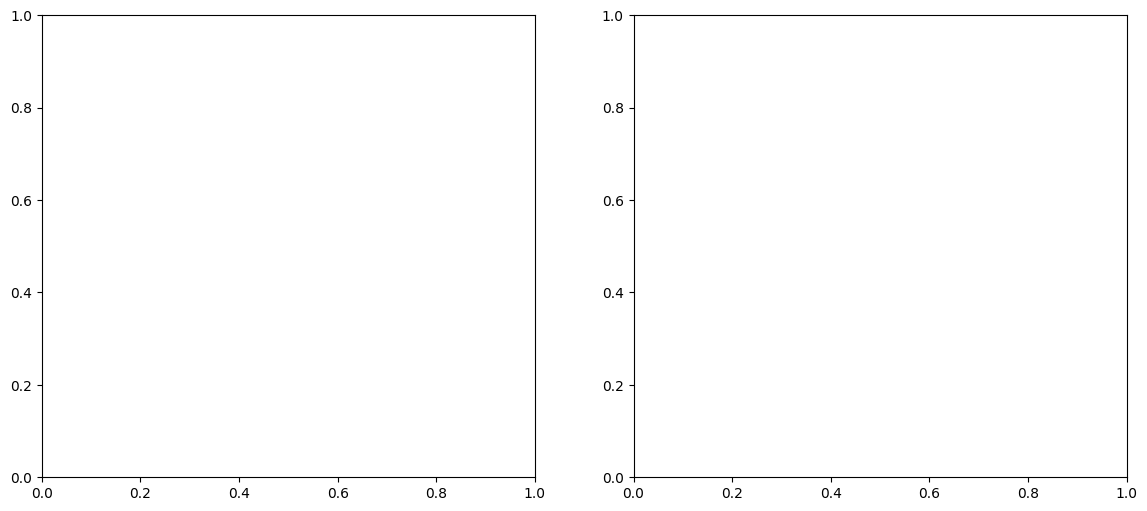

In [6]:
# Visualize the cells colored by type
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Cell positions
ax = axes[0]
scatter = ax.scatter(
    fov.cell_centroids[:, 0],
    fov.cell_centroids[:, 1],
    c=fov.class_instance,
    cmap='Set1',
    s=20, alpha=0.7
)
ax.set_aspect('equal')
ax.set_title('Cell Positions by Type')
plt.colorbar(scatter, ax=ax, label='Cell Type')

# Transcript dots
ax = axes[1]
ax.scatter(dots_df['x'], dots_df['y'], s=1, alpha=0.3, c='red')
ax.set_aspect('equal')
ax.set_title(f'Transcript Dots ({len(dots_df):,} total)')

plt.tight_layout()
plt.show()

In [11]:
# Look at the dots DataFrame structure
print("Dots DataFrame:")
print(dots_df.head(10))
print(f"\nColumns: {list(dots_df.columns)}")

Dots DataFrame:
           x          y     gene  cell
0  20.041088  10.646274   Gene 2     0
1  24.201852  15.812465   Gene 3     0
2  16.995853  14.004143   Gene 3     0
3  25.855206  11.631885   Gene 7     0
4  28.274631  14.167625   Gene 8     0
5  19.113168  16.497035  Gene 46     0
6  29.613238  17.988774   Gene 0     1
7  32.863074  22.003970   Gene 2     1
8  34.201393  13.738351   Gene 3     1
9  32.071839  16.311453   Gene 5     1

Columns: ['x', 'y', 'gene', 'cell']


None


AxisError: axis 1 is out of bounds for array of dimension 1

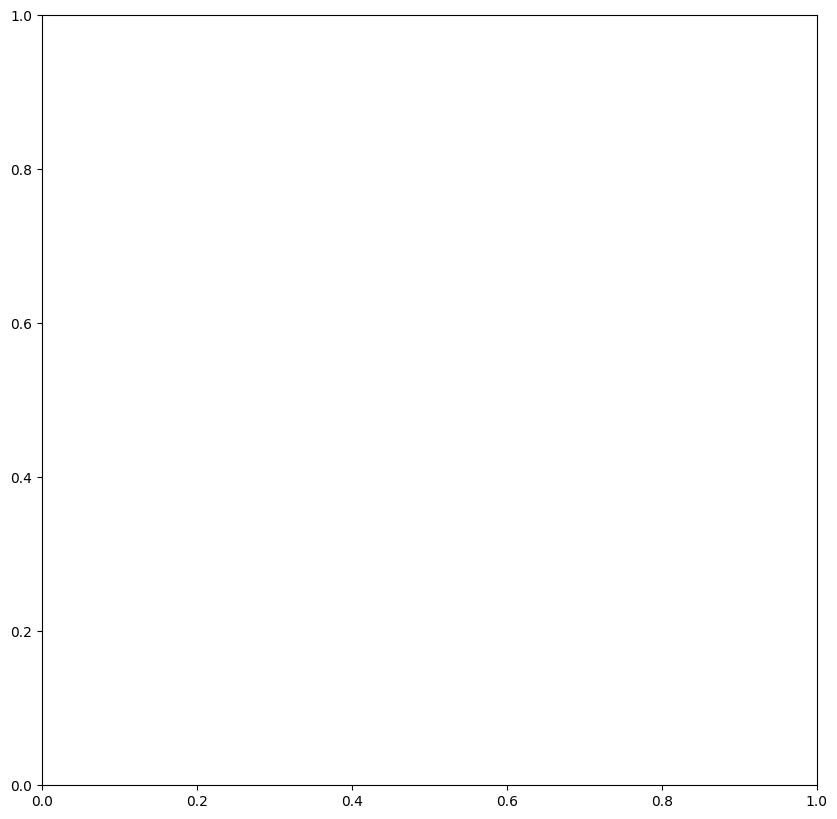

In [12]:
# Try a more complex sample - cortex-like layered tissue
fov_cortex, tissue_cortex, dots_cortex = load_sample("cortex_like")

fig, ax = plt.subplots(figsize=(10, 10))
scatter = ax.scatter(
    fov_cortex.cell_centroids[:, 0],
    fov_cortex.cell_centroids[:, 1],
    c=fov_cortex.class_instance,
    cmap='Set1',
    s=15, alpha=0.6
)
ax.set_aspect('equal')
ax.set_title(f'Cortex-like Tissue\n({len(fov_cortex.cell_centroids)} cells, {tissue_cortex.n_cell_types} types)')
plt.colorbar(scatter, ax=ax, label='Cell Type')
plt.show()

# Notice the layered structure - cell types vary with Y position

---
## 2. Generating Your Own Data (Minimal Example)

Here's the simplest way to generate simulated spatial transcriptomics data.

In [13]:
from pointillsim import (
    TissueCellTypes,
    CellTypesProperties,
    HybISS_Setup,
    FOVDistribution,
    FrameWideElement,
    RandomCellTypeRule,
)

In [14]:
# Step 1: Define tissue expression profiles
tissue = TissueCellTypes()
tissue.generate_types_and_markers(
    n_genes=50,       # Number of genes in panel
    n_cell_types=5,   # Number of cell types
)

# Step 2: Define cell morphology
cell_props = CellTypesProperties(n_cell_types=5)

# Step 3: Create FOV generator
fov_dist = FOVDistribution(
    frame_size=800,
    background_element=lambda: FrameWideElement(
        frame_size=800,
        tipical_cell_spacing=18,
        rules=RandomCellTypeRule(n_cell_types=5)
    ),
)

# Step 4: Generate FOV and apply morphology
fov = fov_dist.generate_fov()
cell_props.apply(fov)

# Step 5: Generate transcript observations
hybiss = HybISS_Setup(tissue)
hybiss.observe_dots(fov)

# Step 6: Export
dots_df = hybiss.make_pandas_df()
cells_df = fov.make_pandas_df()

print(f"Generated {len(cells_df)} cells with {len(dots_df)} transcript dots")

[[1 0 0 0 0]
 [0 0 0 1 0]
 [1 0 0 0 0]
 ...
 [0 0 0 1 0]
 [0 0 0 1 0]
 [0 1 0 0 0]]
[[1 0 0 0 0]
 [0 0 0 1 0]
 [1 0 0 0 0]
 ...
 [0 0 0 1 0]
 [0 0 0 1 0]
 [0 1 0 0 0]]
Generated 2244 cells with 17970 transcript dots


[[1 0 0 0 0]
 [0 0 0 1 0]
 [1 0 0 0 0]
 ...
 [0 0 0 1 0]
 [0 0 0 1 0]
 [0 1 0 0 0]]


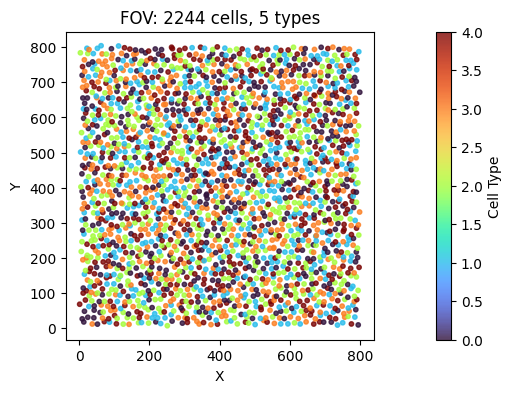

In [18]:
# Visualize
from pointillsim import plot_fov

fig, axes = plot_fov(
    fov, 
    figsize=(16, 4)
)
plt.show();

---
## 3. Understanding the Output

PointillSim produces two main outputs:

### Cells DataFrame (`cells_df`)
Contains ground truth information about each cell.

In [19]:
print("Cells DataFrame columns:")
print(cells_df.columns.tolist())
print(f"\nShape: {cells_df.shape}")
print("\nFirst 5 rows:")
cells_df.head()

Cells DataFrame columns:
['X', 'Y', 'Class ID', 'Class 0', 'Class 1', 'Class 2', 'Class 3', 'Class 4', 'ProbClass0', 'ProbClass1', 'ProbClass2', 'ProbClass3', 'ProbClass4', 'Minor Axis', 'Major Axis', 'Rotation', 'RNA Concentration', 'Color_string']

Shape: (2244, 18)

First 5 rows:


,X,Y,Class ID,Class 0,Class 1,Class 2,Class 3,Class 4,ProbClass0,ProbClass1,ProbClass2,ProbClass3,ProbClass4,Minor Axis,Major Axis,Rotation,RNA Concentration,Color_string
0,13.303910,17.999278,0,1,0,0,0,0,0.228143,0.257093,0.427179,0.057281,0.030305,10.752005,11.733148,2.262078,1.060856,"(np.float64(0.12156862745098039), np.float64(0..."
1,37.319754,12.204890,3,0,0,0,1,0,0.229794,0.020520,0.443263,0.222705,0.083718,10.086158,16.535920,5.588830,0.923890,"(np.float64(1.0), np.float64(0.733333333333333..."
2,52.150079,11.775289,0,1,0,0,0,0,0.675919,0.017374,0.061231,0.172421,0.073056,8.239223,12.048226,4.337869,0.982561,"(np.float64(0.12156862745098039), np.float64(0..."
3,71.774355,19.026970,4,0,0,0,0,1,0.483479,0.012449,0.146203,0.163902,0.193967,12.009274,13.411746,0.913719,0.996409,"(np.float64(0.17254901960784313), np.float64(0..."
4,86.451386,17.403025,1,0,1,0,0,0,0.064537,0.099112,0.405641,0.047396,0.383313,11.800269,16.038103,3.714336,0.866390,"(np.float64(0.6823529411764706), np.float64(0...."


Key columns:
- `X`, `Y`: Cell centroid coordinates
- `Class ID`: Realized cell type (integer)
- `Class 0`, `Class 1`, ...: One-hot encoded cell type
- `ProbClass0`, `ProbClass1`, ...: Soft probabilities (ground truth)
- `Minor Axis`, `Major Axis`, `Rotation`: Cell morphology
- `RNA Concentration`: Relative RNA content

### Dots DataFrame (`dots_df`)
Contains observed transcript positions.

In [20]:
print("Dots DataFrame columns:")
print(dots_df.columns.tolist())
print(f"\nShape: {dots_df.shape}")
print("\nFirst 10 rows:")
dots_df.head(10)

Dots DataFrame columns:
['x', 'y', 'gene', 'cell']

Shape: (17970, 4)

First 10 rows:


,x,y,gene,cell
0,9.132566,18.015278,Gene 5,0
1,14.448222,13.564233,Gene 5,0
2,15.863791,18.076068,Gene 5,0
3,11.235468,14.217477,Gene 6,0
4,13.928987,15.510081,Gene 8,0
5,17.537589,17.288936,Gene 33,0
6,10.283908,21.872598,Gene 44,0
7,41.336160,10.026297,Gene 34,1
8,34.683208,10.315295,Gene 34,1
9,33.605939,10.162955,Gene 34,1


Key columns:
- `x`, `y`: Transcript dot coordinates
- `gene`: Gene name
- `cell`: Index of the cell this transcript belongs to

In [21]:
# Gene counts per cell type
import pandas as pd

dots_with_type = dots_df.merge(
    cells_df[['Class ID']].reset_index().rename(columns={'index': 'cell'}),
    on='cell'
)

# Pivot to get counts matrix
gene_counts = dots_with_type.groupby(['Class ID', 'gene']).size().unstack(fill_value=0)
print("Transcripts per cell type (first 10 genes):")
gene_counts.iloc[:, :10]

Transcripts per cell type (first 10 genes):


gene,Gene 0,Gene 1,Gene 10,Gene 11,Gene 12,Gene 13,Gene 14,Gene 15,Gene 16,Gene 17
Class ID,,,,,,,,,,
0,80,295,1,0,0,0,0,59,12,5
1,0,181,169,182,148,130,271,790,198,138
2,1,0,59,111,0,0,0,0,0,130
3,0,0,0,5,0,0,0,15,7,4
4,28,0,0,0,140,0,0,0,0,98


---
## 4. Export to AnnData/SpatialData

For integration with standard single-cell analysis tools.

In [24]:
# Export to AnnData (if anndata is installed)
try:
    adata = fov.to_anndata()
    print(f"AnnData object: {adata}")
    print(f"  obs (cells): {adata.obs.shape}")
    print(f"  var (genes): {adata.var.shape}")
    print(f"  spatial coordinates in: obsm['spatial']")
except ImportError:
    print("Install anndata to enable AnnData export: pip install anndata")

[[1 0 0 0 0]
 [0 0 0 1 0]
 [1 0 0 0 0]
 ...
 [0 0 0 1 0]
 [0 0 0 1 0]
 [0 1 0 0 0]]
AnnData object: AnnData object with n_obs × n_vars = 2244 × 5
    obs: 'cell_id', 'class_id', 'minor_axis', 'major_axis', 'rotation', 'rna_concentration'
    var: 'gene_name'
    uns: 'cell_type_probabilities'
    obsm: 'spatial', 'cell_type_one_hot'
  obs (cells): (2244, 6)
  var (genes): (5, 1)
  spatial coordinates in: obsm['spatial']


---
## Next Steps

Now that you've seen the basics, explore these notebooks for more details:

1. **01_simulation_framework.ipynb**: Deep dive into the simulation philosophy and all components
2. **02_elements_and_rules.ipynb**: Creating complex tissue structures with different cell type patterns
3. **03_batch_generation.ipynb**: Generating multiple FOVs and datasets
4. **04_real_expression_data.ipynb**: Using real scRNA-seq data as input